<a href="https://colab.research.google.com/github/TheOnlyMoj/AltSchool-Assignment-2/blob/main/Dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Downloading the Dataset

Fetching the UCI 130-US Hospitals dataset (Strack et al., 2014) directly from the
UCI Machine Learning Repository and unpacking it.

In [ ]:
!wget -q "https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip" -O diabetes.zip
!unzip -o diabetes.zip
!ls

Archive:  diabetes.zip
  inflating: dataset_diabetes/diabetic_data.csv  
  inflating: dataset_diabetes/IDs_mapping.csv  
dataset_diabetes  diabetes.zip	sample_data


## Step 2: Loading the Dataset into Python

Reading the CSV into a pandas dataframe and checking the dataset's size
(expected: 101,766 rows, 50 columns) against the figures stated in the proposal.

In [ ]:
import pandas as pd

df = pd.read_csv("dataset_diabetes/diabetic_data.csv")

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Step 3: Checking Data Quality

Before cleaning, checking key variables for unexpected categories or values.

In [ ]:
#Gender categories
df["gender"].value_counts()

,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3


In [ ]:
#Weight Column
print("weight categories (raw):")
print(df["weight"].value_counts())
print()

weight categories (raw):
weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64



In [ ]:
#readmission
print("readmitted categories:")
print(df["readmitted"].value_counts())


readmitted categories:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [ ]:
weight_missing = (df["weight"] == "?" ).sum()
weight_pct = round(weight_missing / len(df)*100,2)
print(f"Weight missing: {weight_missing} ({weight_pct}%)")

Weight missing: 98569 (96.86%)


## Step 3 (continued): Checking Remaining Columns Before Dropping

Inspecting identifier columns, high-missingness administrative columns,
and medication columns for analytical value before exclusion decisions.

In [ ]:
# Check 1: identifier columns - just confirm they are IDs not clinical values
print("encounter_id sample values:")
print(df["encounter_id"].head())
print()
print("patient_nbr sample values:")
print(df["patient_nbr"].head())
print()

# Check 2: missingness in payer_code and medical_specialty
for col in ["payer_code", "medical_specialty"]:
    n_missing = (df[col] == "?").sum()
    pct_missing = round(n_missing / len(df) * 100, 2)
    print(f"{col}: {n_missing} missing ({pct_missing}%)")
print()

# Check 3: medication columns - check how much variation exists
med_cols = ["examide", "citoglipton", "glimepiride-pioglitazone",
            "metformin-rosiglitazone", "metformin-pioglitazone",
            "acetohexamide", "troglitazone", "tolbutamide", "tolazamide"]
print("Medication column value counts (checking for near-constant columns):")
for col in med_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

encounter_id sample values:
0    2278392
1     149190
2      64410
3     500364
4      16680
Name: encounter_id, dtype: int64

patient_nbr sample values:
0     8222157
1    55629189
2    86047875
3    82442376
4    42519267
Name: patient_nbr, dtype: int64

payer_code: 40256 missing (39.56%)
medical_specialty: 49949 missing (49.08%)

Medication column value counts (checking for near-constant columns):

examide:
examide
No    101766
Name: count, dtype: int64

citoglipton:
citoglipton
No    101766
Name: count, dtype: int64

glimepiride-pioglitazone:
glimepiride-pioglitazone
No        101765
Steady         1
Name: count, dtype: int64

metformin-rosiglitazone:
metformin-rosiglitazone
No        101764
Steady         2
Name: count, dtype: int64

metformin-pioglitazone:
metformin-pioglitazone
No        101765
Steady         1
Name: count, dtype: int64

acetohexamide:
acetohexamide
No        101765
Steady         1
Name: count, dtype: int64

troglitazone:
troglitazone
No        101763
Steady   

In [ ]:
# Check 4: patient_nbr — confirm whether patients contribute more than one encounter
print("Total encounters:", len(df))
print("Unique patients:", df["patient_nbr"].nunique())
print("Encounters per patient - distribution:")
print(df["patient_nbr"].value_counts().describe())

repeat_patients = (df["patient_nbr"].value_counts() > 1).sum()
print(f"\nPatients with more than one encounter: {repeat_patients}")
print(f"Percentage of encounters from repeat patients: {(1 - df['patient_nbr'].nunique()/len(df))*100:.1f}%")

Total encounters: 101766
Unique patients: 71518
Encounters per patient - distribution:
count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
Name: count, dtype: float64

Patients with more than one encounter: 16773
Percentage of encounters from repeat patients: 29.7%


## Step 3 (continued): Checking Missingness in Race

In [ ]:
print("Race raw values:")
print(df["race"].value_counts())
print()
n_missing = (df["race"] == "?").sum()
pct_missing = round(n_missing / len(df) * 100, 2)
print(f"Race missing: {n_missing} rows ({pct_missing}%)")

Race raw values:
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

Race missing: 2273 rows (2.23%)


## Objective 1: Data Preprocessing

Based on the data quality checks above, preparing the dataset for analysis.
Columns are dropped in four groups, each for a distinct reason identified during inspection.

In [ ]:
# --- Group 1: Remove rows with unclear gender (3 rows identified in Step 3) ---
df = df[df["gender"] != "Unknown/Invalid"]

# Step 3 identified that some patients contribute multiple encounters (29.7% of records) —
# retain patient ID separately for clustering, NOT used as a model predictor,
# only to identify which encounters belong to the same patient
cluster_ids = df["patient_nbr"].copy().reset_index(drop=True)

# --- Group 2: Drop identifier columns (no clinical value — arbitrary ID numbers) ---
df = df.drop(columns=["encounter_id", "patient_nbr"])

# --- Group 3: Drop high-missingness columns ---
# weight: 96.86% missing
# payer_code: 39.56% missing
# medical_specialty: 49.08% missing
df = df.drop(columns=["weight", "payer_code", "medical_specialty"])

# --- Group 4: Drop near-constant medication columns (insufficient variation for modelling) ---
# examide and citoglipton: 100% "No" across all records
# remaining columns below: >99.9% "No" with negligible exceptions
df = df.drop(columns=[
    "examide", "citoglipton", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone",
    "acetohexamide", "troglitazone", "tolbutamide", "tolazamide"
])

# --- Group 5: Create binary outcome variable ---
# readmitted recorded as NO / >30 / <30 — recode to 1 if readmitted within 30 days, 0 otherwise
df["readmitted_30d"] = (df["readmitted"] == "<30").astype(int)

# Drop original readmitted column — now redundant, replaced by binary readmitted_30d
df = df.drop(columns=["readmitted"])

# race: excluded from analysis — not part of pre-specified covariate plan
# 2.23% missingness noted but moot given exclusion decision
df = df.drop(columns=["race"])

In [ ]:
print(cluster_ids.shape)

(101763,)


In [ ]:
# Confirm final shape after all preprocessing
print("Shape after preprocessing:", df.shape)
print()
print("Remaining columns:")
print(list(df.columns))

Shape after preprocessing: (101763, 35)

Remaining columns:
['gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'change', 'diabetesMed', 'readmitted_30d']


## Step 4: Exploratory Data Analysis

Examining how age, gender, and readmission are distributed before fitting any models,
to spot patterns and confirm the data behaves as expected.

In [ ]:
df["age"].value_counts().sort_index()

,count
age,
[0-10),161
[10-20),691
[20-30),1657
[30-40),3775
[40-50),9685
[50-60),17256
[60-70),22482
[70-80),26066
[80-90),17197


## Step 4 (continued): Readmission Rate by Age Band

In [ ]:
df.groupby("age")["readmitted_30d"].mean().sort_index()

,readmitted_30d
age,
[0-10),0.018634
[10-20),0.057887
[20-30),0.142426
[30-40),0.112318
[40-50),0.106040
[50-60),0.096662
[60-70),0.111289
[70-80),0.117740
[80-90),0.120835


In [ ]:
df.groupby("gender")["readmitted_30d"].mean()

,readmitted_30d
gender,
Female,0.112452
Male,0.110615


## Step 4: Visualising Readmission Rate by Age Band

Bar chart showing the proportion of patients readmitted within 30 days
across each age band, to illustrate the pattern observed in the raw rates above.

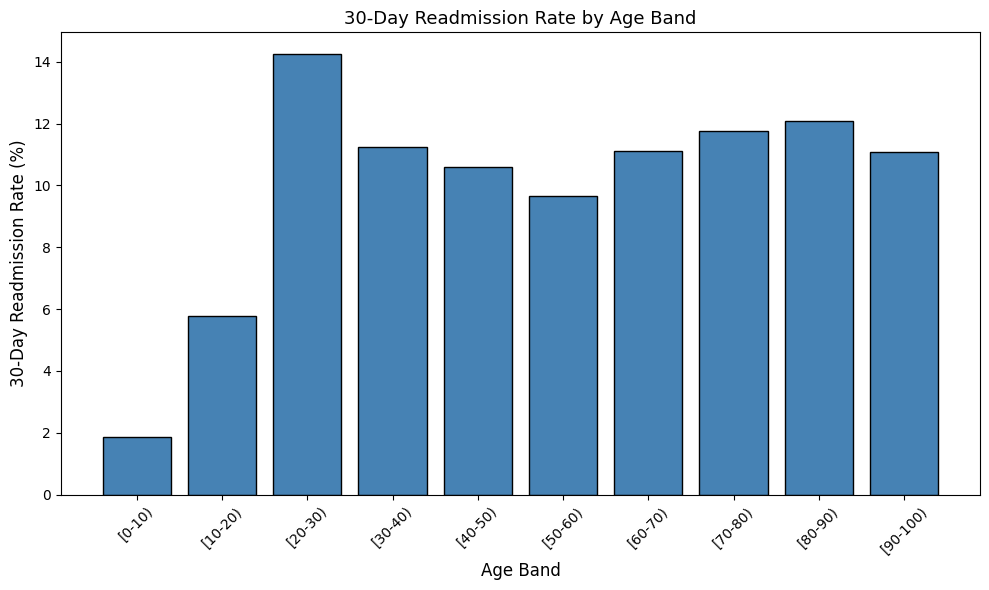

In [ ]:
import matplotlib.pyplot as plt

# Calculate readmission rate by age band
readmission_by_age = df.groupby("age")["readmitted_30d"].mean().sort_index() * 100

# Plot
plt.figure(figsize=(10, 6))
plt.bar(readmission_by_age.index, readmission_by_age.values,
        color="steelblue", edgecolor="black")

plt.xlabel("Age Band", fontsize=12)
plt.ylabel("30-Day Readmission Rate (%)", fontsize=12)
plt.title("30-Day Readmission Rate by Age Band", fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
gender_by_age = df.groupby("age")["gender"].value_counts(normalize=True).unstack()
gender_by_age = gender_by_age * 100
gender_by_age.round(1)

gender,Female,Male
age,,
[0-10),51.6,48.4
[10-20),58.2,41.8
[20-30),67.2,32.8
[30-40),57.3,42.7
[40-50),49.7,50.3
[50-60),49.7,50.3
[60-70),49.2,50.8
[70-80),53.7,46.3
[80-90),61.1,38.9


In [ ]:
df["readmitted_30d"].value_counts(normalize=True)

,proportion
readmitted_30d,
0,0.888398
1,0.111602


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101763 entries, 0 to 101765
Data columns (total 35 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   gender                    101763 non-null  object
 1   age                       101763 non-null  object
 2   admission_type_id         101763 non-null  int64 
 3   discharge_disposition_id  101763 non-null  int64 
 4   admission_source_id       101763 non-null  int64 
 5   time_in_hospital          101763 non-null  int64 
 6   num_lab_procedures        101763 non-null  int64 
 7   num_procedures            101763 non-null  int64 
 8   num_medications           101763 non-null  int64 
 9   number_outpatient         101763 non-null  int64 
 10  number_emergency          101763 non-null  int64 
 11  number_inpatient          101763 non-null  int64 
 12  diag_1                    101763 non-null  object
 13  diag_2                    101763 non-null  object
 14  diag_3   

## Step 4 (continued): Visualising Readmission Rate by Gender

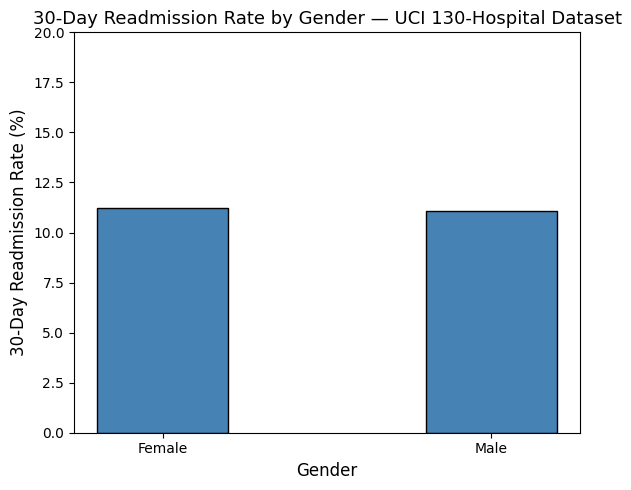

In [ ]:
readmission_by_gender = df.groupby("gender")["readmitted_30d"].mean().sort_index() * 100

plt.figure(figsize=(6, 5))
plt.bar(readmission_by_gender.index, readmission_by_gender.values,
        color="steelblue", edgecolor="black", width=0.4)

plt.xlabel("Gender", fontsize=12)
plt.ylabel("30-Day Readmission Rate (%)", fontsize=12)
plt.title("30-Day Readmission Rate by Gender — UCI 130-Hospital Dataset", fontsize=13)
plt.ylim(0, 20)
plt.tight_layout()
plt.show()

## Step 4 (continued): Gender × Age Band Cross-Tabulation
Examining whether readmission rates differ by gender within each age band,
to inform the age × gender interaction term tested in Objective 3.

In [ ]:
crosstab = df.groupby(["age", "gender"])["readmitted_30d"].agg(["sum", "count", "mean"])
crosstab.columns = ["Readmitted_30d", "Total", "Readmission_Rate"]
crosstab["Readmission_Rate"] = (crosstab["Readmission_Rate"] * 100).round(1)
crosstab

Readmitted_30d  Total  Readmission_Rate
age      gender                                         
[0-10)   Female               1     83               1.2
         Male                 2     78               2.6
[10-20)  Female              24    402               6.0
         Male                16    289               5.5
[20-30)  Female             177   1114              15.9
         Male                59    543              10.9
[30-40)  Female             242   2162              11.2
         Male               182   1613              11.3
[40-50)  Female             511   4811              10.6
         Male               516   4874              10.6
[50-60)  Female             851   8572               9.9
         Male               817   8684               9.4
[60-70)  Female            1206  11061              10.9
         Male              1296  11421              11.3
[70-80)  Female            1635  13985              11.7
         Male              1434  12081              11.9
[80-90)  Female            1282  10515              12.2
         Male               796   6682              11.9
[90-100) Female             223   2003              11.1
         Male                87    790              11.0

## Step 5: Variable Encoding

Encoding categorical variables into numeric format before regression.
Each variable is inspected first before encoding decisions are made.

In [ ]:
print("Insulin raw values:")
print(df["insulin"].value_counts())

Insulin raw values:
insulin
No        47380
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64


## Step 5 (continued): Encoding Categorical Variables

Gender encoded as binary (Female=0, Male=1).
Insulin encoded as binary (No=0, any insulin=1) — used as a covariate
capturing treatment intensity rather than specific dose direction.
Age encoded as dummy variables with [70-80) as reference category,
justified by the non-monotonic pattern observed in EDA.

In [ ]:
# --- Gender: binary encoding ---
df["gender"] = (df["gender"] == "Male").astype(int)
print("Gender encoded:")
print(df["gender"].value_counts())
print()

# --- Insulin: binary encoding ---
df["insulin"] = (df["insulin"] != "No").astype(int)
print("Insulin encoded:")
print(df["insulin"].value_counts())
print()

# --- Age: dummy variable encoding, reference category = [70-80) ---
age_dummies = pd.get_dummies(df["age"], prefix="age").astype(int)
age_dummies = age_dummies.drop(columns=["age_[70-80)"])
df = pd.concat([df, age_dummies], axis=1)
df = df.drop(columns=["age"])

print("Age dummy columns created:")
print([col for col in df.columns if col.startswith("age_")])
print()
print("Shape after encoding:", df.shape)

Gender encoded:
gender
0    54708
1    47055
Name: count, dtype: int64

Insulin encoded:
insulin
1    54383
0    47380
Name: count, dtype: int64

Age dummy columns created:
['age_[0-10)', 'age_[10-20)', 'age_[20-30)', 'age_[30-40)', 'age_[40-50)', 'age_[50-60)', 'age_[60-70)', 'age_[80-90)', 'age_[90-100)']

Shape after encoding: (101763, 43)


In [ ]:
import statsmodels.api as sm
print("statsmodels available")

statsmodels available


## Objective 2: Univariable Logistic Regression

Each predictor variable is regressed individually against readmitted_30d.
Results (odds ratios, 95% confidence intervals, p-values) are reported
descriptively. All six variables are pre-specified and will enter the
multivariable model regardless of individual p-values — this step
satisfies Objective 2 only.

In [ ]:
import statsmodels.api as sm
import numpy as np

# Variables for univariable analysis
# Age dummies treated as one variable (all 9 dummies together in one model)
age_cols = [col for col in df.columns if col.startswith("age_")]
single_vars = ["gender", "number_inpatient", "number_emergency",
               "number_diagnoses", "insulin"]

def run_univariable(df, cols, label, cluster_ids):
    """Run a single univariable logistic regression with cluster-robust
    standard errors and return OR, CI, p-value"""
    X = df[cols]
    X = sm.add_constant(X)
    y = df["readmitted_30d"]
    model = sm.Logit(y, X).fit(disp=0, cov_type='cluster', cov_kwds={'groups': cluster_ids})

    results = []
    for col in cols:
        OR = np.exp(model.params[col])
        CI_low = np.exp(model.conf_int().loc[col, 0])
        CI_high = np.exp(model.conf_int().loc[col, 1])
        p = model.pvalues[col]
        results.append({
            "Variable": col,
            "OR": round(OR, 3),
            "95% CI Lower": round(CI_low, 3),
            "95% CI Upper": round(CI_high, 3),
            "p-value": round(p, 4)
        })
    return results

all_results = []

# Run age dummies together as one model
print("Running univariable model: age")
all_results.extend(run_univariable(df, age_cols, "age", cluster_ids))

# Run each remaining variable individually
for var in single_vars:
    print(f"Running univariable model: {var}")
    all_results.extend(run_univariable(df, [var], var, cluster_ids))

# Display as a clean table
results_df = pd.DataFrame(all_results)
print()
print(results_df.to_string(index=False))

Running univariable model: age
Running univariable model: gender
Running univariable model: number_inpatient
Running univariable model: number_emergency
Running univariable model: number_diagnoses
Running univariable model: insulin

        Variable    OR  95% CI Lower  95% CI Upper  p-value
      age_[0-10) 0.142         0.046         0.440   0.0007
     age_[10-20) 0.460         0.318         0.666   0.0000
     age_[20-30) 1.244         0.928         1.669   0.1445
     age_[30-40) 0.948         0.823         1.092   0.4608
     age_[40-50) 0.889         0.806         0.980   0.0183
     age_[50-60) 0.802         0.744         0.864   0.0000
     age_[60-70) 0.938         0.882         0.999   0.0456
     age_[80-90) 1.030         0.966         1.098   0.3637
    age_[90-100) 0.936         0.819         1.069   0.3264
          gender 0.982         0.937         1.028   0.4356
number_inpatient 1.331         1.316         1.347   0.0000
number_emergency 1.165         1.107         1.

## Step 6: Variance Inflation Factor (VIF) Check

Checking for multicollinearity among predictor variables before building
the multivariable model. Threshold set at VIF < 5. Variables with VIF ≥ 5
would indicate problematic correlation with other predictors.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assemble all variables going into the multivariable model
model_vars = age_cols + ["gender", "number_inpatient",
                         "number_emergency", "number_diagnoses", "insulin"]

X_vif = df[model_vars].copy()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

# Exclude the constant row, flag anything >= 5
vif_data = vif_data[vif_data["Variable"] != "const"].reset_index(drop=True)
vif_data["Flag"] = vif_data["VIF"].apply(lambda x: "⚠️ CHECK" if x >= 5 else "✓ OK")

print(vif_data.to_string(index=False))

        Variable      VIF Flag
      age_[0-10) 1.017273 ✓ OK
     age_[10-20) 1.052039 ✓ OK
     age_[20-30) 1.076823 ✓ OK
     age_[30-40) 1.127147 ✓ OK
     age_[40-50) 1.263473 ✓ OK
     age_[50-60) 1.391835 ✓ OK
     age_[60-70) 1.454825 ✓ OK
     age_[80-90) 1.384919 ✓ OK
    age_[90-100) 1.080924 ✓ OK
          gender 1.013031 ✓ OK
number_inpatient 1.095028 ✓ OK
number_emergency 1.089673 ✓ OK
number_diagnoses 1.109748 ✓ OK
         insulin 1.025052 ✓ OK


## Objective 3: Multivariable Logistic Regression

All six pre-specified variables entered simultaneously using forced entry (not stepwise). Age (9 dummy variables, reference [70-80)), gender, number_inpatient, number_emergency, number_diagnoses, and insulin.

Because Step 3 identified that some patients contribute multiple encounters, cluster-robust standard errors (grouped by patient) are used as the primary inferential approach, with the ordinary (non-clustered) model retained alongside for comparison.

In [ ]:
# Assemble predictor variables — all pre-specified, forced entry
model_vars = age_cols + ["gender", "number_inpatient",
                         "number_emergency", "number_diagnoses", "insulin"]

X = df[model_vars]
X = sm.add_constant(X)
y = df["readmitted_30d"]

# Fit the multivariable model — cluster-robust standard errors used as primary,
# since patients may contribute multiple encounters (see clustering check above)
multi_model_clustered = sm.Logit(y, X).fit(disp=0, cov_type='cluster', cov_kwds={'groups': cluster_ids})

# Ordinary (non-clustered) model retained for the sensitivity comparison
multi_model = sm.Logit(y, X).fit(disp=0)

# Extract odds ratios, confidence intervals, p-values — from the primary (clustered) model
multi_results = pd.DataFrame({
    "Variable": multi_model_clustered.params.index,
    "OR": np.exp(multi_model_clustered.params),
    "95% CI Lower": np.exp(multi_model_clustered.conf_int()[0]),
    "95% CI Upper": np.exp(multi_model_clustered.conf_int()[1]),
    "p-value": multi_model_clustered.pvalues
}).drop(index="const").reset_index(drop=True)

multi_results["OR"] = multi_results["OR"].round(3)
multi_results["95% CI Lower"] = multi_results["95% CI Lower"].round(3)
multi_results["95% CI Upper"] = multi_results["95% CI Upper"].round(3)
multi_results["p-value"] = multi_results["p-value"].round(4)

print("=== MAIN-EFFECTS MODEL (cluster-robust, primary) ===")
print(multi_results.to_string(index=False))
print()
print("Model AUC-ROC:")
from sklearn.metrics import roc_auc_score
y_pred_prob = multi_model_clustered.predict(X)
print(round(roc_auc_score(y, y_pred_prob), 4))

=== MAIN-EFFECTS MODEL (cluster-robust, primary) ===
        Variable    OR  95% CI Lower  95% CI Upper  p-value
      age_[0-10) 0.211         0.068         0.651   0.0068
     age_[10-20) 0.527         0.374         0.742   0.0002
     age_[20-30) 0.911         0.765         1.086   0.2996
     age_[30-40) 0.892         0.792         1.004   0.0587
     age_[40-50) 0.840         0.775         0.911   0.0000
     age_[50-60) 0.793         0.741         0.849   0.0000
     age_[60-70) 0.935         0.882         0.990   0.0217
     age_[80-90) 1.026         0.966         1.089   0.4092
    age_[90-100) 0.946         0.836         1.072   0.3843
          gender 1.007         0.966         1.049   0.7461
number_inpatient 1.313         1.297         1.330   0.0000
number_emergency 1.033         1.009         1.058   0.0072
number_diagnoses 1.053         1.040         1.065   0.0000
         insulin 1.159         1.113         1.208   0.0000

Model AUC-ROC:
0.63


In [ ]:
age_indices = [X.columns.get_loc(c) for c in age_cols]
wald_test = multi_model_clustered.wald_test(np.eye(len(X.columns))[age_indices], scalar=True)
print("=== H1 OMNIBUS TEST (cluster-robust Wald test, primary) ===")
print(f"Chi-square: {round(wald_test.statistic, 3)}")
print(f"Degrees of freedom: {len(age_indices)}")
print(f"p-value: {wald_test.pvalue}")

=== H1 OMNIBUS TEST (cluster-robust Wald test, primary) ===
Chi-square: 83.786
Degrees of freedom: 9
p-value: 2.849596221853841e-14


## Objective 3 (continued): Multivariable Model with Age × Gender Interaction Term

Testing H3: whether the effect of age on readmission differs by gender.
Interaction terms created by multiplying each age dummy by gender.
Reference category remains [70-80). All main effects retained in the model.

In [ ]:
# Create interaction terms: each age dummy × gender
interaction_cols = []
for col in age_cols:
    interaction_name = f"{col}_x_gender"
    df[interaction_name] = df[col] * df["gender"]
    interaction_cols.append(interaction_name)

# Build interaction model — main effects + interaction terms + covariates
interaction_vars = (age_cols + ["gender"] + interaction_cols +
                   ["number_inpatient", "number_emergency",
                    "number_diagnoses", "insulin"])

X_int = sm.add_constant(df[interaction_vars])
y = df["readmitted_30d"]

# Fit the interaction model — cluster-robust standard errors used as primary
interaction_model_clustered = sm.Logit(y, X_int).fit(disp=0, cov_type='cluster', cov_kwds={'groups': cluster_ids})

# Ordinary (non-clustered) model retained for sensitivity comparison
interaction_model = sm.Logit(y, X_int).fit(disp=0)

# Extract results for interaction terms only — from the primary (clustered) model
int_results = pd.DataFrame({
    "Variable": interaction_cols,
    "OR": np.exp(interaction_model_clustered.params[interaction_cols]).round(3),
    "95% CI Lower": np.exp(interaction_model_clustered.conf_int().loc[interaction_cols, 0]).round(3),
    "95% CI Upper": np.exp(interaction_model_clustered.conf_int().loc[interaction_cols, 1]).round(3),
    "p-value": interaction_model_clustered.pvalues[interaction_cols].round(4)
}).reset_index(drop=True)

print("=== INTERACTION TERMS (age × gender), cluster-robust, primary ===")
print(int_results.to_string(index=False))

=== INTERACTION TERMS (age × gender), cluster-robust, primary ===
             Variable    OR  95% CI Lower  95% CI Upper  p-value
  age_[0-10)_x_gender 2.255         0.207        24.572   0.5045
 age_[10-20)_x_gender 0.943         0.466         1.907   0.8706
 age_[20-30)_x_gender 0.893         0.607         1.315   0.5678
 age_[30-40)_x_gender 1.001         0.792         1.264   0.9963
 age_[40-50)_x_gender 1.060         0.903         1.245   0.4746
 age_[50-60)_x_gender 0.963         0.841         1.102   0.5820
 age_[60-70)_x_gender 1.063         0.947         1.193   0.3004
 age_[80-90)_x_gender 0.969         0.858         1.095   0.6128
age_[90-100)_x_gender 1.000         0.752         1.330   0.9997


In [ ]:
interaction_indices = [X_int.columns.get_loc(c) for c in interaction_cols]
wald_test_int = interaction_model_clustered.wald_test(np.eye(len(X_int.columns))[interaction_indices], scalar=True)
print("=== H3 OMNIBUS TEST (cluster-robust Wald test, primary) ===")
print(f"Chi-square: {round(wald_test_int.statistic, 3)}")
print(f"Degrees of freedom: {len(interaction_indices)}")
print(f"p-value: {wald_test_int.pvalue}")

=== H3 OMNIBUS TEST (cluster-robust Wald test, primary) ===
Chi-square: 4.187
Degrees of freedom: 9
p-value: 0.8986673576498084


##Objective 4: Model Fit and Sensitivity Check

The primary omnibus test for age (H1) is the cluster-robust Wald test reported above (Objective 3). This section reports the equivalent ordinary likelihood ratio test as a sensitivity check, comparing the full model against a reduced model with all age dummies removed.

Goodness-of-fit is reported via Hosmer-Lemeshow test, McFadden's Pseudo R², and AIC — appropriate metrics for an associational logistic regression study. These are unaffected by the choice of standard errors, since they depend only on the fitted coefficients, not the covariance matrix.

In [ ]:
from scipy import stats

# ── 1. OMNIBUS / JOINT TEST FOR AGE (H1) ─────────────────────────────────────
# Reduced model: gender + 4 covariates only (all 9 age dummies removed)
reduced_vars = ["gender", "number_inpatient", "number_emergency",
                "number_diagnoses", "insulin"]

X_reduced = sm.add_constant(df[reduced_vars])
reduced_model = sm.Logit(y, X_reduced).fit(disp=0)

# Likelihood ratio statistic
lr_age = 2 * (multi_model.llf - reduced_model.llf)
lr_age_df = len(age_cols)  # 9 degrees of freedom (one per age dummy)
lr_age_p = stats.chi2.sf(lr_age, lr_age_df)

print("=== OMNIBUS TEST FOR AGE (H1) — ordinary LR test, sensitivity check ===")
print(f"Likelihood Ratio Chi-square: {round(lr_age, 3)}")
print(f"Degrees of freedom: {lr_age_df}")
print(f"p-value: {round(lr_age_p, 4)}")
print()


# ── 2. PSEUDO R² (McFadden's) ────────────────────────────────────────────────
print("=== GOODNESS OF FIT ===")
print(f"McFadden's Pseudo R²: {round(multi_model.prsquared, 4)}")
print()


# ── 3. AIC ───────────────────────────────────────────────────────────────────
print(f"AIC: {round(multi_model.aic, 3)}")
print()


# ── 4. HOSMER-LEMESHOW TEST (manual implementation) ──────────────────────────
# Step 1: get predicted probabilities from the full model
y_pred = multi_model.predict(X)

# Step 2: sort patients into 10 equal groups by predicted probability
hl_df = pd.DataFrame({"y_true": y.values, "y_pred": y_pred.values})
hl_df["decile"] = pd.qcut(hl_df["y_pred"], q=10, labels=False)

# Step 3: for each group, count observed events and compute expected events
hl_grouped = hl_df.groupby("decile").agg(
    observed=("y_true", "sum"),
    expected=("y_pred", "sum"),
    n=("y_true", "count")
).reset_index()

# Step 4: compute HL statistic
# Formula: sum of (O - E)² / (E * (1 - E/n)) across all groups
hl_grouped["hl_component"] = (
    (hl_grouped["observed"] - hl_grouped["expected"]) ** 2 /
    (hl_grouped["expected"] * (1 - hl_grouped["expected"] / hl_grouped["n"]))
)
hl_stat = hl_grouped["hl_component"].sum()

# Step 5: compare to chi-square with 8 df (10 groups - 2)
hl_p = stats.chi2.sf(hl_stat, df=8)

print("=== HOSMER-LEMESHOW TEST ===")
print(f"HL Chi-square: {round(hl_stat, 3)}")
print(f"Degrees of freedom: 8")
print(f"p-value: {round(hl_p, 4)}")
print()
print("Note: HL p > 0.05 indicates acceptable model fit")
print("      HL p < 0.05 indicates poor fit")

=== OMNIBUS TEST FOR AGE (H1) — ordinary LR test, sensitivity check ===
Likelihood Ratio Chi-square: 99.339
Degrees of freedom: 9
p-value: 0.0

=== GOODNESS OF FIT ===
McFadden's Pseudo R²: 0.0332

AIC: 68873.277

=== HOSMER-LEMESHOW TEST ===
HL Chi-square: 104.014
Degrees of freedom: 8
p-value: 0.0

Note: HL p > 0.05 indicates acceptable model fit
      HL p < 0.05 indicates poor fit


In [ ]:
df["gender"].value_counts(normalize=True)

,proportion
gender,
0,0.537602
1,0.462398
